# Trades Explorer

Three cells:
1. **Setup** — paths, loaders, helpers.
2. **Past profits** — pulls every settled 15-min window, shows cum P&L + per-window table.
3. **Define `show_trades(pick, view)`** — reusable. Pick can be an int index, a slice, a list of indices, a date string, or an epoch ts. View can be `'table'`, `'chart'`, or `'both'`.
4. **Usage** — edit just this cell; no scrolling required to try a new pick.

Data sources (written live by the server):
- `data/window_pnl.jsonl` — one row per settled window
- `data/arb_trades.jsonl` — one row per settled trade
- `data/predictions.jsonl` — per-second snapshots used to draw the chart

In [127]:
import json
from pathlib import Path
import pandas as pd
import datetime as dt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
WINDOW_PNL_PATH  = REPO_ROOT / "data" / "window_pnl.jsonl"
ARB_TRADES_PATH  = REPO_ROOT / "data" / "arb_trades.jsonl"
PREDICTIONS_PATH = REPO_ROOT / "data" / "predictions.jsonl"

def load_jsonl(path):
    if not path.exists():
        return pd.DataFrame()
    rows = []
    with open(path) as f:
        for line in f:
            try: rows.append(json.loads(line))
            except json.JSONDecodeError: continue
    return pd.DataFrame(rows)

def load_predictions_for_window(window_open_ts):
    if not PREDICTIONS_PATH.exists():
        return pd.DataFrame()
    rows = []
    with open(PREDICTIONS_PATH) as f:
        for line in f:
            try: r = json.loads(line)
            except json.JSONDecodeError: continue
            if r.get("window_open_ts") == window_open_ts:
                rows.append(r)
    return pd.DataFrame(rows).sort_values("sample_sec").reset_index(drop=True) if rows else pd.DataFrame()

print(f"REPO_ROOT = {REPO_ROOT}")
for p in (WINDOW_PNL_PATH, ARB_TRADES_PATH, PREDICTIONS_PATH):
    print(f"  {p.name}: {'exists' if p.exists() else 'MISSING'}")

REPO_ROOT = /Users/Harish/highlowticker-tui/btc-predictor
  window_pnl.jsonl: exists
  arb_trades.jsonl: exists
  predictions.jsonl: exists


## Cell 1 — fetch all past profits

Loads every settled window, computes per-window P&L, cumulative P&L, hit-rate, and shows a quick chart.

=== Profits across 158 settled windows ===
  Range:           2026-05-23 22:30 EDT  →  2026-05-25 14:15 EDT
  Total P&L:       $+772.26
  Per-window avg:  $+4.888
  Per-hour avg:    $+19.55
  Positive windows:86/158  (54%)
  Total trades:    8986   (6084W / 2902L  hit-rate 68%)



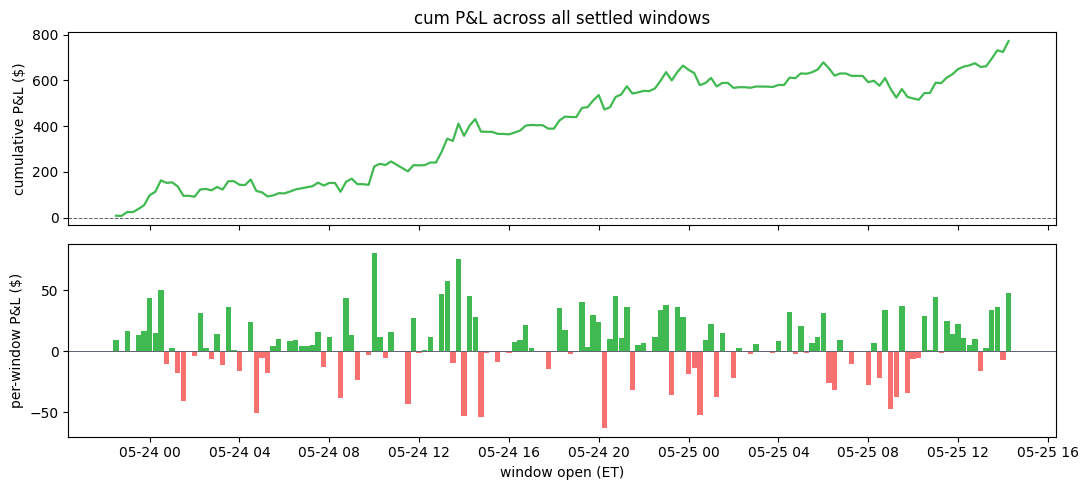

,window_et,outcome,delta_bps,params,trades,wins,losses,pnl,cum_pnl
157,05/25 14:15 EDT,DOWN,-0.60,K 0.55/0.30 Δ 8/4pp,101,101,0,$+47.450,$+772.260
156,05/25 14:00 EDT,UP,+8.37,K 0.60/0.30 Δ 15/4pp,15,0,15,$-6.970,$+724.810
155,05/25 13:45 EDT,DOWN,-1.13,K 0.60/0.30 Δ 15/4pp,83,83,0,$+36.070,$+731.780
154,05/25 13:30 EDT,DOWN,-8.01,K 0.55/0.50 Δ 6/4pp,102,102,0,$+33.710,$+695.710
153,05/25 13:15 EDT,DOWN,-5.70,K 0.55/0.50 Δ 6/4pp,8,8,0,$+2.580,$+662.000
152,05/25 13:00 EDT,DOWN,-6.64,K 0.50/0.55 Δ 4/4pp,69,26,43,$-16.070,$+659.420
151,05/25 12:45 EDT,UP,+8.38,K 0.30/0.55 Δ 4/4pp,43,43,0,$+9.600,$+675.490
150,05/25 12:30 EDT,UP,+12.86,K 0.35/0.50 Δ 4/4pp,15,15,0,$+5.280,$+665.890
149,05/25 12:15 EDT,UP,+7.33,K 0.35/0.55 Δ 4/4pp,28,28,0,$+10.950,$+660.610
148,05/25 12:00 EDT,DOWN,-14.32,K 0.35/0.55 Δ 4/4pp,120,105,15,$+22.426,$+649.660


In [128]:
import matplotlib.pyplot as plt

windows = load_jsonl(WINDOW_PNL_PATH)
trades  = load_jsonl(ARB_TRADES_PATH)

if windows.empty:
    print("No window_pnl.jsonl yet — server hasn't settled any windows.")
else:
    windows = windows.sort_values("window_open_ts").reset_index(drop=True)
    windows["window_utc"] = pd.to_datetime(windows["window_open_ts"], unit="s", utc=True)
    windows["window_et"]  = windows["window_utc"].dt.tz_convert("America/New_York")
    windows["cum_pnl"]    = windows["pnl"].cumsum()
    th = pd.json_normalize(windows["thresholds"])
    windows = pd.concat([windows.drop(columns=["thresholds"]), th], axis=1)
    windows["params"] = windows.apply(
        lambda r: f"K {r['k_yes']:.2f}/{r['k_no']:.2f} \u0394 {int(r['d_yes']*100)}/{int(r['d_no']*100)}pp",
        axis=1,
    )

    total_pnl = windows["pnl"].sum()
    n_windows = len(windows)
    n_pos     = (windows["pnl"] > 0).sum()
    total_n   = windows["trades"].sum()
    total_w   = windows["wins"].sum()
    total_l   = windows["losses"].sum()
    hit_rate  = total_w / max(total_n, 1) * 100
    print(f"=== Profits across {n_windows} settled windows ===")
    print(f"  Range:           {windows['window_et'].iloc[0]:%Y-%m-%d %H:%M %Z}  \u2192  {windows['window_et'].iloc[-1]:%Y-%m-%d %H:%M %Z}")
    print(f"  Total P&L:       ${total_pnl:+.2f}")
    print(f"  Per-window avg:  ${total_pnl / n_windows:+.3f}")
    print(f"  Per-hour avg:    ${total_pnl / (n_windows/4):+.2f}")
    print(f"  Positive windows:{n_pos}/{n_windows}  ({100*n_pos/n_windows:.0f}%)")
    print(f"  Total trades:    {total_n}   ({total_w}W / {total_l}L  hit-rate {hit_rate:.0f}%)")
    print()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    ax1.plot(windows["window_et"], windows["cum_pnl"], lw=1.6, color="#3fb950")
    ax1.axhline(0, color="#5b6470", lw=0.7, ls="--")
    ax1.set_ylabel("cumulative P&L ($)")
    ax1.set_title("cum P&L across all settled windows")
    colors = windows["pnl"].apply(lambda v: "#3fb950" if v >= 0 else "#f87171")
    ax2.bar(windows["window_et"], windows["pnl"], color=colors, width=0.01)
    ax2.axhline(0, color="#5b6470", lw=0.7)
    ax2.set_ylabel("per-window P&L ($)")
    ax2.set_xlabel("window open (ET)")
    plt.tight_layout(); plt.show()

    cols = ["window_et", "outcome", "delta_bps", "params", "trades", "wins", "losses", "pnl", "cum_pnl"]
    display(windows[cols].iloc[::-1].head(50).style.format({
        "delta_bps": "{:+.2f}", "pnl": "${:+.3f}", "cum_pnl": "${:+.3f}",
        "window_et": lambda t: t.strftime("%m/%d %H:%M %Z"),
    }))

## Cell 2 — define `show_trades(pick, view)`

Reusable inspector. Run this cell once, then call `show_trades(...)` from the next cell as many times as you like.

**`pick` accepts:**
- `-1` — last window (negative index counts from end)
- `slice(-4, -1)` — last 3 windows (Python slice semantics, end-exclusive)
- `(-4, -1)` — same as above (tuple shorthand)
- `[-3, -2, -1]` — explicit list of indices
- `"2026-05-25 11:00"` — a single window by date (ET assumed)
- `1779628500` — a single window by epoch seconds

**`view` accepts:** `'table'` · `'chart'` · `'both'` (default)

In [129]:
import plotly.graph_objects as go

def _resolve_single_ts(p, windows_df):
    """Translate a single pick element into a window_open_ts (float, epoch s UTC)."""
    if windows_df.empty:
        raise ValueError("No windows in window_pnl.jsonl yet.")
    if isinstance(p, bool):
        raise TypeError("bool is not a valid pick")
    if isinstance(p, int) and -len(windows_df) <= p < len(windows_df):
        return float(windows_df["window_open_ts"].iloc[p])
    if isinstance(p, (int, float)) and p > 1_000_000_000:
        return float(p)
    if isinstance(p, str):
        s = p.replace(" ET", "").strip()
        ts = pd.to_datetime(s)
        if ts.tzinfo is None:
            ts = ts.tz_localize("America/New_York")
        return float((int(ts.timestamp()) // 900) * 900)
    raise ValueError(f"unparseable pick element: {p!r}")

def _resolve_picks(pick, windows_df):
    """Return an ordered list of window_open_ts values from the user's `pick`."""
    if pick is None:
        return [float(windows_df["window_open_ts"].iloc[-1])]
    if isinstance(pick, slice):
        return [float(t) for t in windows_df["window_open_ts"].iloc[pick]]
    if isinstance(pick, tuple) and len(pick) == 2 and all(isinstance(x, (int, type(None))) for x in pick):
        return [float(t) for t in windows_df["window_open_ts"].iloc[slice(*pick)]]
    if isinstance(pick, (list, tuple)):
        return [_resolve_single_ts(p, windows_df) for p in pick]
    return [_resolve_single_ts(pick, windows_df)]

def _render_summary(wts, windows_df):
    window_et = pd.to_datetime(wts, unit="s", utc=True).tz_convert("America/New_York")
    wrow = windows_df[windows_df["window_open_ts"] == wts]
    if wrow.empty:
        print(f"=== Window {window_et:%Y-%m-%d %H:%M %Z} — (no settled summary yet) ===")
        return None
    w = wrow.iloc[0]
    print(f"=== Window {window_et:%Y-%m-%d %H:%M %Z}  ({w['outcome']} {w['delta_bps']:+.2f} bps) ===")
    print(f"  Open  ${w['open_px']:>10,.2f}  \u2192  Close ${w['close_px']:>10,.2f}")
    print(f"  Active params: {w['params']}")
    print(f"  Trades: {w['trades']}   {w['wins']}W / {w['losses']}L   P&L ${w['pnl']:+.3f}")
    return w

def _render_table(wts, trades_df):
    ts = trades_df[trades_df["window_open_ts"] == wts].copy()
    if ts.empty:
        print("(No per-trade rows for this window.)")
        return ts
    ts["wall_et"] = pd.to_datetime(ts["wall_ts"], unit="s", utc=True).dt.tz_convert("America/New_York")
    ts["edge_pp"] = ts["delta_pp"] * 100
    ts = ts.sort_values("sample_sec").reset_index(drop=True)
    yes = ts[ts["direction"] == "BUY YES"]
    no  = ts[ts["direction"] == "BUY NO"]
    print(f"=== {len(ts)} trades in this window ===")
    print(f"  BUY YES: n={len(yes):>3}   avg entry ${(yes['entry_ask'].mean() if len(yes) else 0):.3f}   P&L ${yes['pnl'].sum():+.3f}")
    print(f"  BUY NO : n={len(no):>3}   avg entry ${(no['entry_ask'].mean() if len(no) else 0):.3f}   P&L ${no['pnl'].sum():+.3f}")
    cols = ["wall_et", "sample_sec", "direction", "model_p", "market_mid",
            "entry_bid", "entry_ask", "edge_pp", "status", "pnl"]
    display(ts[cols].style.format({
        "model_p":    "{:.3f}",   "market_mid": "{:.3f}",
        "entry_bid":  "{:.3f}",   "entry_ask":  "{:.3f}",
        "edge_pp":    "+{:.1f}pp",
        "pnl":        "${:+.3f}",
        "wall_et":    lambda t: t.strftime("%H:%M:%S"),
    }))
    return ts

def _render_chart(wts, trades_df, windows_df):
    preds = load_predictions_for_window(wts)
    if preds.empty:
        print("(No predictions.jsonl rows for this window — chart skipped.)")
        return
    preds["yes_mid"] = (preds["kalshi_yes_bid"] + preds["kalshi_yes_ask"]) / 2.0
    ts = trades_df[trades_df["window_open_ts"] == wts].copy()
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=preds["sample_sec"], y=preds["yes_mid"],
        mode="lines", name="Kalshi P(UP)",
        line=dict(color="#58a6ff", width=2),
        hovertemplate="T+%{x}s · Kalshi YES = %{y:.3f}<extra></extra>",
    ))
    fig.add_hline(y=0.5, line=dict(color="#5b6470", width=1, dash="dash"),
                  annotation_text="50%", annotation_position="right")
    if not ts.empty:
        yes_tr = ts[ts["direction"] == "BUY YES"]
        no_tr  = ts[ts["direction"] == "BUY NO"]
        if not yes_tr.empty:
            fig.add_trace(go.Scatter(
                x=yes_tr["sample_sec"], y=yes_tr["entry_ask"],
                mode="markers", name=f"BUY YES (n={len(yes_tr)})",
                marker=dict(symbol="triangle-up", size=12, color="#3fb950",
                            line=dict(color="#0a4a1f", width=1)),
                customdata=list(zip(yes_tr["pnl"], yes_tr["status"])),
                hovertemplate=("T+%{x}s · BUY YES @ $%{y:.3f}<br>"
                               "P&L $%{customdata[0]:+.3f}  (%{customdata[1]})"
                               "<extra></extra>"),
            ))
        if not no_tr.empty:
            no_tr = no_tr.assign(yes_axis_y=lambda d: 1 - d["entry_ask"])
            fig.add_trace(go.Scatter(
                x=no_tr["sample_sec"], y=no_tr["yes_axis_y"],
                mode="markers", name=f"BUY NO (n={len(no_tr)})",
                marker=dict(symbol="triangle-down", size=12, color="#f87171",
                            line=dict(color="#4a0d0d", width=1)),
                customdata=list(zip(no_tr["entry_ask"], no_tr["pnl"], no_tr["status"])),
                hovertemplate=("T+%{x}s · BUY NO @ $%{customdata[0]:.3f}"
                               " (implied P(UP) %{y:.3f})<br>"
                               "P&L $%{customdata[1]:+.3f}  (%{customdata[2]})"
                               "<extra></extra>"),
            ))
    window_et = pd.to_datetime(wts, unit="s", utc=True).tz_convert("America/New_York")
    title = f"Kalshi YES · {window_et:%m/%d %H:%M %Z}"
    wrow = windows_df[windows_df["window_open_ts"] == wts]
    if not wrow.empty:
        w = wrow.iloc[0]
        title += f" — {w['outcome']} {w['delta_bps']:+.2f} bps · P&L ${w['pnl']:+.2f}"
    fig.update_layout(
        title=title,
        paper_bgcolor="#161b22", plot_bgcolor="#0e1116",
        font=dict(color="#e6edf3", family="ui-monospace, Menlo, monospace", size=11),
        xaxis=dict(title="seconds into 15-min window", range=[0, 900],
                   gridcolor="#23272d", zerolinecolor="#30363d",
                   tickvals=list(range(0, 901, 60))),
        yaxis=dict(title="P(YES) / price", range=[0, 1], tickformat=".0%",
                   gridcolor="#23272d", zerolinecolor="#30363d"),
        legend=dict(orientation="h", y=-0.18, x=0.5, xanchor="center"),
        height=420, margin=dict(l=60, r=20, t=50, b=60),
        hovermode="closest",
    )
    fig.show()

def show_trades(pick=-1, view="both"):
    """Render summary + table and/or chart for one or many windows.

    pick: int / slice / (start, stop) tuple / list / str / epoch ts (see markdown above)
    view: 'table' | 'chart' | 'both'
    """
    if view not in {"table", "chart", "both"}:
        raise ValueError(f"view must be 'table', 'chart', or 'both' — got {view!r}")
    if windows.empty:
        print("window_pnl.jsonl is empty — nothing to show."); return
    ts_list = _resolve_picks(pick, windows)
    if not ts_list:
        print("No windows matched the pick."); return
    for i, wts in enumerate(ts_list):
        if i > 0:
            print("\n" + "=" * 80 + "\n")
        _render_summary(wts, windows)
        print()
        if view in ("table", "both"):
            _render_table(wts, trades)
        if view in ("chart", "both"):
            _render_chart(wts, trades, windows)

print("show_trades() is ready. Try it from the next cell.")

show_trades() is ready. Try it from the next cell.


## Cell 3 — usage

Edit just this cell to try different picks/views. No scrolling required.

```python
show_trades(-1)                     # latest window, table + chart
show_trades(-1, view="table")       # latest window, table only
show_trades(-1, view="chart")       # latest window, chart only
show_trades(slice(-4, -1))          # last 3 windows (indices -4, -3, -2)
show_trades((-4, -1))               # same — tuple shorthand for the slice
show_trades([-3, -2, -1])           # explicit list of indices
show_trades("2026-05-25 11:00")     # by date (ET)
show_trades(1779628500)             # by epoch ts (UTC)
```

In [132]:
show_trades((-3, -1),view="chart")

=== Window 2026-05-25 13:45 EDT  (DOWN -1.13 bps) ===
  Open  $ 77,513.13  →  Close $ 77,504.38
  Active params: K 0.60/0.30 Δ 15/4pp
  Trades: 83   83W / 0L   P&L $+36.070





=== Window 2026-05-25 14:00 EDT  (UP +8.37 bps) ===
  Open  $ 77,504.15  →  Close $ 77,569.00
  Active params: K 0.60/0.30 Δ 15/4pp
  Trades: 15   0W / 15L   P&L $-6.970

